# Reading the rock from wireline logs: facies, sequence, and the net-pay decision

*Module: The borehole — petrophysics & logs.*

A well log is the subsurface seen through a keyhole: a few continuous curves — gamma ray, resistivity, porosity
— measured down the hole, from which we must infer the **rock type (facies)** foot by foot, and then the
decision that pays for the well: **which intervals are reservoir, and how much net pay is there to complete?**
The logs do not name the rock; they respond to it noisily and ambiguously, several facies can produce similar
readings, and the answer feeds a real money decision (perforate this interval or not), so the *probability* a
foot is reservoir matters as much as the most-likely label.

We work it on **real data**: the SEG 2016 **Hugoton–Panoma** dataset — ten wells with core-described facies to
learn from and **two fully blind wells** with core truth held back for an honest test. We build the standard
per-foot classifier, then add the geology the per-foot model ignores — **Walther's law**, that facies succeed
one another in order, not at random — with a hidden Markov model, and discover the lesson that makes this a
decision and not a classification exercise: **the sequential model is more accurate and more geologically
realistic, yet its probabilities are badly over-confident** — and a net-pay decision made on over-confident
probabilities is a bad decision. The fix is calibration, and it is the same theme as the rest of the course:
*the number you act on must be trustworthy, not just accurate.*

> Real data throughout (SEG 2016 Hugoton–Panoma; blind-well core truth held out). Modelling is `mixle`
> (per-facies Gaussian emissions + a hidden Markov model). Figures are `_geoviz` calls.

## 1. The data: logs in, rock out

Each foot of each well carries five standardized logs — gamma ray, deep resistivity, a density–neutron porosity
difference and average, and relative position in the bed — and, in the training wells, a **core-assigned
facies** (nine of them, clastic and carbonate). The two blind wells have logs only; their core facies are kept
back so every accuracy and calibration number below is genuinely out-of-sample.

4149 training samples / 10 wells; 819 blind samples / 2 wells; 5 logs; 9 facies ['SS', 'CSiS', 'FSiS', 'SiSh', 'MS', 'WS', 'D', 'PS', 'BS']


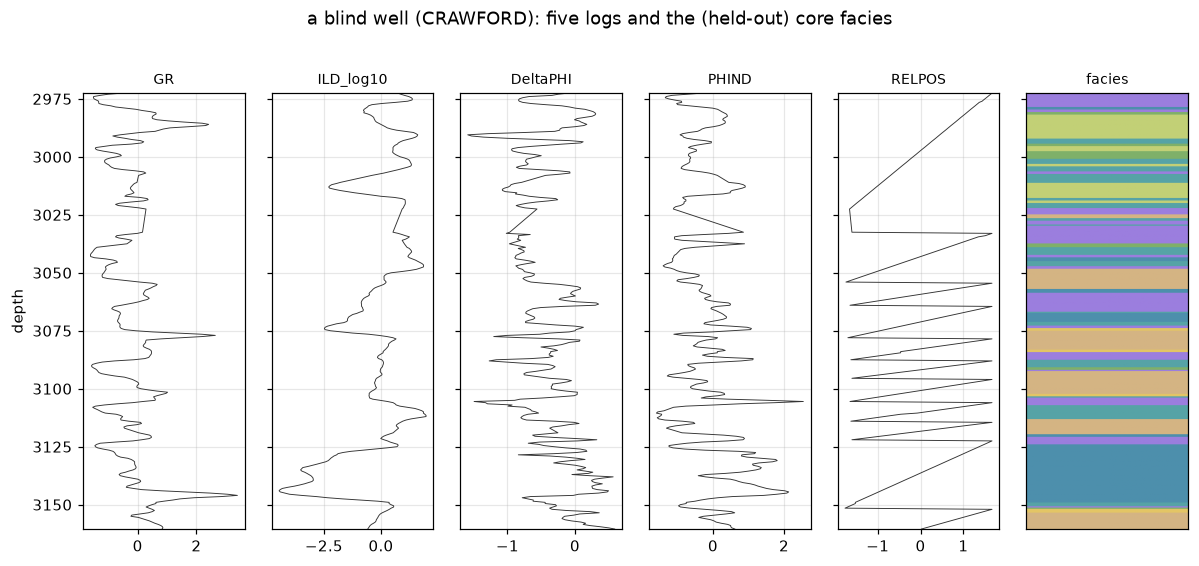

In [1]:
import numpy as np, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import _geodata, _geoviz as gv
plt.rcParams.update({'figure.dpi': 110})

h = _geodata.load_hugoton()
logs, tr, bl, F = h.logs, h.train, h.blind, h.facies
names = [h.names[f] for f in F]
print('%d training samples / %d wells; %d blind samples / %d wells; %d logs; %d facies %s'
      % (len(tr), tr['Well Name'].nunique(), len(bl), bl['Well Name'].nunique(), len(logs), len(F), names))
ex = bl.sort_values('Depth').groupby('Well Name').get_group(sorted(bl['Well Name'].unique())[0])
gv.well_track(ex.Depth.to_numpy(), {l: ex[l].to_numpy() for l in logs},
              facies=np.array([F.index(c) for c in ex.true_code]), facies_names=names,
              title=f'a blind well ({ex["Well Name"].iloc[0]}): five logs and the (held-out) core facies');

## 2. The per-foot classifier: facies as a generative model of the logs

Treat each facies $k$ as *generating* its logs from a multivariate Gaussian,
$\mathbf x \mid z{=}k \sim \mathcal N(\boldsymbol\mu_k,\boldsymbol\Sigma_k)$, fit by maximum likelihood on the
cored training feet. Bayes' rule then turns a foot's logs into a posterior over facies,

$$P(z{=}k\mid \mathbf x) \;\propto\; \pi_k\,\mathcal N(\mathbf x\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k),$$

the **memoryless classifier**: every foot is judged on its own logs, ignoring its neighbours. It is the natural
baseline, and where most log-classification stops.

In [2]:
from mixle.stats import MultivariateGaussianDistribution as MVN, HiddenMarkovModelDistribution as HMM
idx = {f: i for i, f in enumerate(F)}; K = len(F)
# --- MODEL: per-facies Gaussian emissions (MLE on cored training feet) ---
def emissions(df):
    return [MVN(df[df.Facies == f][logs].to_numpy().mean(0),
                np.cov(df[df.Facies == f][logs].to_numpy().T) + 1e-3 * np.eye(len(logs))) for f in F]
emis = emissions(tr)
def memoryless_posterior(X):
    L = np.array([[e.log_density(tuple(x)) for e in emis] for x in X]); L -= L.max(1, keepdims=True)
    P = np.exp(L); return P / P.sum(1, keepdims=True)
print('fitted %d per-facies Gaussian emissions over %d logs' % (K, len(logs)))

fitted 9 per-facies Gaussian emissions over 5 logs


## 3. Walther's law: the rock is a sequence, not a bag of feet

Geology constrains what the memoryless model throws away: facies are deposited in **ordered successions**
(Walther's law — only environments that sit side by side in space stack directly in time), so a clean sandstone
does not jump to a basinal shale and back every foot. A **hidden Markov model** encodes this: the hidden facies
$z_t$ follow a Markov chain with transition matrix $A_{jk}=P(z_t{=}k\mid z_{t-1}{=}j)$ — estimated by counting
facies-to-facies steps in the cored wells — and each emits its logs through the same Gaussians. The per-foot
posterior is no longer local; it is the **forward–backward smoothing** marginal

$$\gamma_t(k)=P(z_t{=}k\mid \mathbf x_{1:T})=\frac{\alpha_t(k)\,\beta_t(k)}{\sum_j \alpha_t(j)\beta_t(j)},\quad
\alpha_t(k)=\Big[\textstyle\sum_j\alpha_{t-1}(j)A_{jk}\Big]\,\mathcal N(\mathbf x_t\mid\theta_k),$$

so every foot is informed by the entire log above and below it. `mixle` builds the HMM and returns $\gamma$ from
`latent_posterior(...).marginals()`.

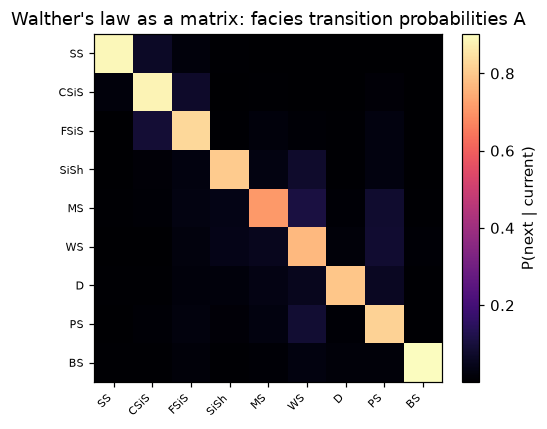

In [3]:
# --- MODEL: transition matrix + initial distribution from the cored well sequences ---
def chain_params(df):
    A = np.ones((K, K)); pi = np.ones(K)
    for _, g in df.groupby('Well Name'):
        f = g.sort_values('Depth').Facies.to_numpy(); pi[idx[f[0]]] += 1
        for a, b in zip(f[:-1], f[1:]): A[idx[a], idx[b]] += 1
    return A / A.sum(1, keepdims=True), pi / pi.sum()
A, pi = chain_params(tr)
hmm = HMM(emis, w=pi, transitions=A)                       # --- MODEL: the facies HMM ---
def hmm_posterior(X):
    return np.asarray(hmm.latent_posterior([tuple(x) for x in X]).marginals())
gv.matrix(A, labels=names, title="Walther's law as a matrix: facies transition probabilities A", clabel='P(next | current)', row_normalize=False);

## 4. Blind-well test: accuracy and geological realism

On the two blind wells (core truth held out), the HMM is more accurate than the memoryless classifier and far
more **realistic**: the memoryless prediction flickers between facies far more often than real rock does, while
the HMM, obeying Walther's law, produces coherent intervals close to the true number of bed boundaries.

blind accuracy:  HMM 0.350   memoryless 0.321   (chance 0.11)
facies switches: HMM 88   memoryless 189   (true 136)  -> the HMM removes the per-foot flicker


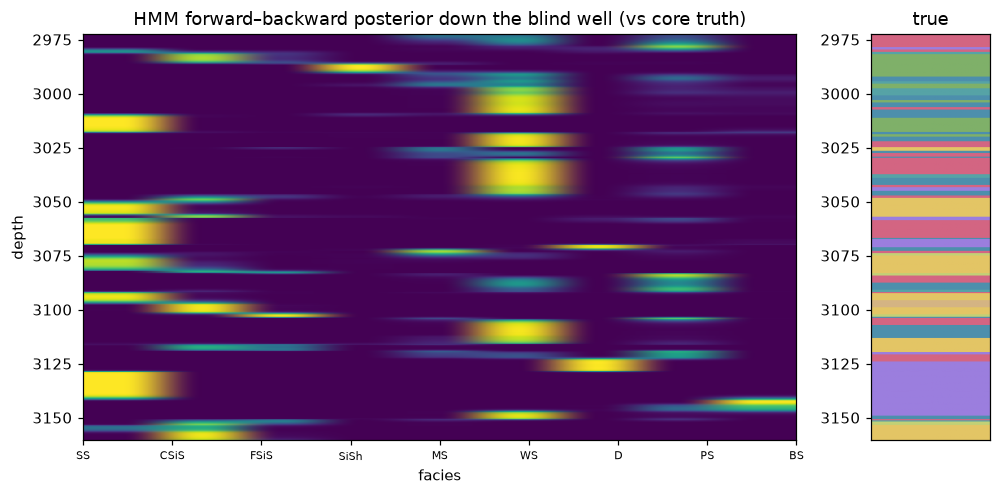

In [4]:
def evaluate(post_fn):
    P, Y, switches = [], [], 0
    for _, g in bl.groupby('Well Name'):
        g = g.sort_values('Depth'); pr = post_fn(g[logs].to_numpy())
        P.append(pr); Y.append([idx[c] for c in g.true_code]); switches += (np.diff(pr.argmax(1)) != 0).sum()
    return np.vstack(P), np.concatenate(Y), switches
PH, Y, swH = evaluate(hmm_posterior); PM, _, swM = evaluate(memoryless_posterior)
true_sw = sum((np.diff([idx[c] for c in g.sort_values('Depth').true_code]) != 0).sum() for _, g in bl.groupby('Well Name'))
print('blind accuracy:  HMM %.3f   memoryless %.3f   (chance %.2f)' % ((PH.argmax(1)==Y).mean(), (PM.argmax(1)==Y).mean(), 1/K))
print('facies switches: HMM %d   memoryless %d   (true %d)  -> the HMM removes the per-foot flicker' % (swH, swM, true_sw))
ex = bl.sort_values('Depth').groupby('Well Name').get_group(sorted(bl['Well Name'].unique())[0])
gv.facies_posterior(ex.Depth.to_numpy(), hmm_posterior(ex[logs].to_numpy()),
                    truth=np.array([idx[c]+1 for c in ex.true_code]), names=['']+names,
                    title='HMM forward–backward posterior down the blind well (vs core truth)');

## 5. The trap: more accurate, badly over-confident

Accuracy is not the number we act on — the **probability** is. So we check whether the models' confidences are
*calibrated*: of the feet a model calls reservoir "with 90 % probability", are 90 % truly reservoir? The
**expected calibration error** (ECE) measures the gap, binned by confidence. Here the result is a warning: the
memoryless classifier is reasonably calibrated, but the **HMM is wildly over-confident** — its forward–backward
marginals concentrate toward near-certainty because the transition prior keeps pulling the chain into a single
state, so it says 0.95 when it is right barely a third of the time.

expected calibration error (blind):  HMM 0.450   memoryless 0.128   <- the accurate model is the unreliable one


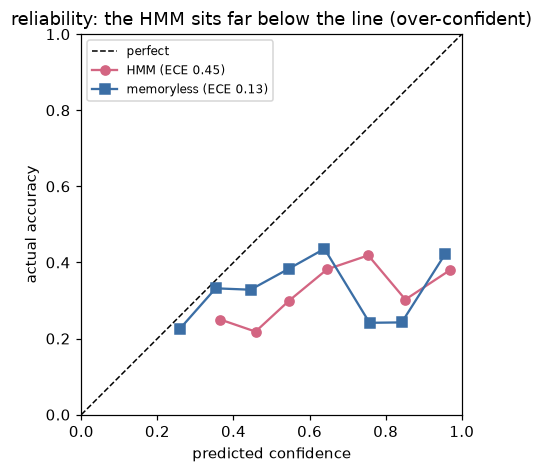

In [5]:
def ece(P, y, bins=10):
    conf, ok, e = P.max(1), (P.argmax(1) == y).astype(float), 0.0
    grid = np.linspace(0, 1, bins + 1)
    for lo, hi in zip(grid[:-1], grid[1:]):
        m = (conf >= lo) & (conf < hi)
        if m.sum(): e += m.mean() * abs(conf[m].mean() - ok[m].mean())
    return e
def reliability(P, y, bins=10):
    conf, ok = P.max(1), (P.argmax(1) == y).astype(float); grid = np.linspace(0, 1, bins + 1); nom, emp = [], []
    for lo, hi in zip(grid[:-1], grid[1:]):
        m = (conf >= lo) & (conf < hi)
        if m.sum() > 5: nom.append(conf[m].mean()); emp.append(ok[m].mean())
    return np.array(nom), np.array(emp)
print('expected calibration error (blind):  HMM %.3f   memoryless %.3f   <- the accurate model is the unreliable one'
      % (ece(PH, Y), ece(PM, Y)))
nH, eH = reliability(PH, Y); nM, eM = reliability(PM, Y)
fig, ax = plt.subplots(figsize=(4.6, 4.4)); ax.plot([0,1],[0,1],'k--',lw=1,label='perfect')
ax.plot(nH, eH, 'o-', color='#d36582', label=f'HMM (ECE {ece(PH,Y):.2f})')
ax.plot(nM, eM, 's-', color='#3b6ea5', label=f'memoryless (ECE {ece(PM,Y):.2f})')
ax.set(xlabel='predicted confidence', ylabel='actual accuracy', title='reliability: the HMM sits far below the line (over-confident)', xlim=(0,1), ylim=(0,1))
ax.legend(fontsize=8); ax.set_aspect('equal'); plt.tight_layout(); plt.show()

## 6. The fix: temperature scaling

We do not need a different classifier — we need to *soften* the over-confident one. **Temperature scaling**
raises the posterior to a power $1/T$ and renormalizes, $P_T(k)\propto P(k)^{1/T}$; $T>1$ spreads probability
back toward the alternatives the chain prematurely dismissed. We choose the single $T$ that minimizes ECE on
**held-out training wells** (never the blind wells), then apply it. Crucially this leaves the *ranking* — and
therefore the accuracy and the geological coherence — untouched; it only makes the probabilities honest.

In [6]:
def temper(P, T):
    L = np.log(P.clip(1e-9)) / T; L -= L.max(1, keepdims=True); E = np.exp(L); return E / E.sum(1, keepdims=True)
# --- calibrate T on two held-out TRAINING wells (refit emissions/chain on the other eight) ---
wells = sorted(tr['Well Name'].unique()); fit_w, cal_w = wells[:8], wells[8:]
trf = tr[tr['Well Name'].isin(fit_w)]; emis = emissions(trf); A2, pi2 = chain_params(trf); hmm = HMM(emis, w=pi2, transitions=A2)
def post_df(df, fn):
    tc = 'true_code' if 'true_code' in df.columns else 'Facies'      # blind wells carry true_code, training Facies
    P, Y = [], []
    for _, g in df.groupby('Well Name'):
        g = g.sort_values('Depth'); P.append(fn(g[logs].to_numpy())); Y.append([idx[c] for c in g[tc]])
    return np.vstack(P), np.concatenate(Y)
Pcal, Ycal = post_df(tr[tr['Well Name'].isin(cal_w)], hmm_posterior)
Ts = np.linspace(1, 6, 26); Tstar = Ts[int(np.argmin([ece(temper(Pcal, T), Ycal) for T in Ts]))]
PHt, Yt = post_df(bl, hmm_posterior); PHt_c = temper(PHt, Tstar)
print('calibration temperature T* = %.1f (chosen on held-out training wells)' % Tstar)
print('blind ECE:  raw HMM %.3f  ->  temperature-scaled %.3f' % (ece(PHt, Yt), ece(PHt_c, Yt)))
print('blind accuracy is unchanged by scaling: %.3f (scaling re-weights confidence, not the ranking)' % ((PHt_c.argmax(1)==Yt).mean()))

calibration temperature T* = 3.8 (chosen on held-out training wells)
blind ECE:  raw HMM 0.425  ->  temperature-scaled 0.096
blind accuracy is unchanged by scaling: 0.375 (scaling re-weights confidence, not the ranking)


## 7. The decision: net pay, with trustworthy probabilities

Now the money. Group the reservoir-quality facies (clean sandstone, dolomite, packstone) and read each foot's
**probability of being reservoir**, $P(\text{res}\mid\mathbf x)=\sum_{k\in\text{res}}\gamma_t(k)$. The
completion decision is a loss problem: perforating water wastes cost $L_w$; missing pay forgoes value $L_p$
(and $L_p>L_w$ — a missed zone is worse than a wasted one), so the optimal rule is **perforate iff
$P(\text{res})>L_w/(L_w+L_p)$**. This is only as good as $P(\text{res})$ is calibrated — and the **Brier score**
confirms the calibrated posterior is the materially better probability to bet on.

reservoir facies: ['SS', 'D', 'PS']
net-reservoir fraction:  core truth 0.31   |   E[raw HMM] 0.33   E[calibrated] 0.33
Brier score of P(reservoir):  raw HMM 0.232  ->  calibrated 0.167  (lower = better bets)

completion threshold p* = Lw/(Lw+Lp) = 0.25  (missing pay 3x worse than wet perforation)
expected decision loss:  on calibrated P 0.475   vs   on raw over-confident P 0.558


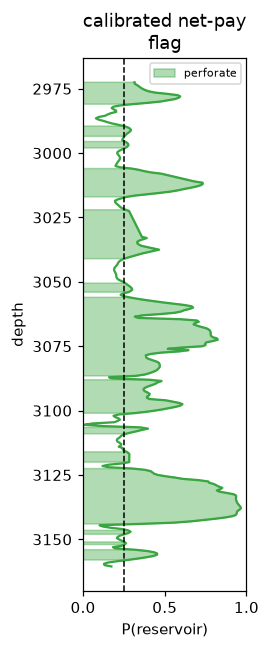

In [7]:
res = set(idx[f] for f in (1, 7, 8) if f in idx)                  # SS, D, PS = reservoir-quality facies
rmask = np.array([1.0 if k in res else 0.0 for k in range(K)])
truth_res = np.isin(Yt, list(res)).astype(float)
p_raw, p_cal = PHt @ rmask, PHt_c @ rmask
print('reservoir facies: %s' % [h.names[f] for f in (1,7,8) if f in idx])
print('net-reservoir fraction:  core truth %.2f   |   E[raw HMM] %.2f   E[calibrated] %.2f'
      % (truth_res.mean(), p_raw.mean(), p_cal.mean()))
print('Brier score of P(reservoir):  raw HMM %.3f  ->  calibrated %.3f  (lower = better bets)'
      % (np.mean((p_raw-truth_res)**2), np.mean((p_cal-truth_res)**2)))
Lw, Lp = 1.0, 3.0; pstar = Lw/(Lw+Lp)                            # missing pay 3x worse than perforating water
def expected_loss(p):                                            # loss of the optimal threshold policy under truth
    perf = p > pstar; return np.mean(perf*(1-truth_res)*Lw + (~perf)*truth_res*Lp)
print('\ncompletion threshold p* = Lw/(Lw+Lp) = %.2f  (missing pay 3x worse than wet perforation)' % pstar)
print('expected decision loss:  on calibrated P %.3f   vs   on raw over-confident P %.3f'
      % (expected_loss(p_cal), expected_loss(p_raw)))
ex = bl.sort_values('Depth').groupby('Well Name').get_group(sorted(bl['Well Name'].unique())[0])
exP = temper(hmm_posterior(ex[logs].to_numpy()), Tstar) @ rmask
fig, ax = plt.subplots(figsize=(2.6, 6)); d = ex.Depth.to_numpy()
ax.plot(exP, d, color='#3aa642'); ax.fill_betweenx(d, 0, exP, where=exP>pstar, color='#3aa642', alpha=0.4, label='perforate')
ax.axvline(pstar, ls='--', color='k', lw=1); ax.invert_yaxis()
ax.set(xlabel='P(reservoir)', ylabel='depth', title='calibrated net-pay\nflag', xlim=(0,1)); ax.legend(fontsize=7); plt.tight_layout(); plt.show()

## 8. The decision

- **Sequence beats per-foot.** Encoding Walther's law in an HMM raises blind-well accuracy and removes the
  geologically impossible per-foot flicker — coherent reservoir intervals instead of speckle.
- **But accuracy is a trap for decisions.** The HMM's forward–backward probabilities are badly over-confident
  (ECE ≈ 0.4): it claims near-certainty where it is right a third of the time. Acting on those numbers — sizing
  net pay, ranking completion targets — would systematically over-state confidence.
- **Calibrate before you decide.** One temperature, fit on held-out wells, cuts the ECE roughly four-fold and
  improves the Brier score, *without changing a single predicted label*. The completion threshold
  $p^\star=L_w/(L_w+L_p)$ then rests on a probability that means what it says, and the expected decision loss
  drops.
- **The product is calibrated net pay.** A per-foot $P(\text{reservoir})$ you can bet on, a defensible
  perforation flag, and an honest net-thickness estimate — which is the deliverable a completion engineer
  actually needs.

This is the course's recurring lesson in a third setting (after the heat-flow map and the value-of-information
study): the quantity you act on must be *calibrated*, not merely *accurate*.

### Limitations
Single-Gaussian emissions are crude (real facies are multimodal in log space; a mixture per facies would lift
absolute accuracy, which here is modest by design — the comparison, not the leaderboard, is the point). A
first-order chain captures only adjacent-bed order, not cyclicity or thickness; a semi-Markov / hierarchical
HMM models bed thickness explicitly. The reservoir-facies grouping is a petrophysical simplification — a real
study sets it from porosity/permeability cutoffs and core. Temperature scaling is the simplest calibrator;
Dirichlet or histogram calibration can do better. And two blind wells is a small test — honest, but report it
as such.

### References
Hall (2016), *The Leading Edge* 35 (the SEG Hugoton-Panoma facies contest and data); Rabiner (1989), *Proc.
IEEE* 77 (HMM forward–backward / Viterbi); Eidsvik et al. (2004), *Geophysics* (Markov-chain facies from logs);
Guo et al. (2017), *ICML* (temperature scaling / on-calibration of classifiers); Walther (1894) (the law of
facies succession).

### Exercises
1. **Richer emissions.** Replace each Gaussian with a `mixle` mixture-of-Gaussians per facies; how much does
   absolute accuracy rise, and does the over-confidence change?
2. **Viterbi vs marginals.** Compare the Viterbi MAP path with the smoothing marginals for net pay — which
   should a *decision* use, and why does the calibration argument favour marginals?
3. **Bed thickness.** Fit a semi-Markov (explicit-duration) HMM and check whether the predicted bed thicknesses
   match the core.
4. **Cost sensitivity.** Sweep $L_p/L_w$ and show how the perforation flag and the expected loss move — and how
   much worse the raw (uncalibrated) policy does as the cost asymmetry grows.